# 🔥 Customer Churn Deep Dive + Action Plan
### Telco Customer Churn Analysis
> **Goal:** Identify why customers leave, predict who's at risk, and build an actionable Churn Playbook.

**Tools:** Python | pandas | scikit-learn | matplotlib | seaborn  
**Dataset:** Telco Customer Churn (7,043 customers, 21 features)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')
print("✅ Libraries loaded successfully")


✅ Libraries loaded successfully


## 📂 Step 1: Load & Understand the Data

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Fix TotalCharges (has spaces → convert to numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Convert Churn to binary
df['Churn_Binary'] = (df['Churn'] == 'Yes').astype(int)

print(f"📊 Dataset Shape: {df.shape}")
print(f"\n🔍 Churn Distribution:")
print(df['Churn'].value_counts())
print(f"\n📉 Overall Churn Rate: {df['Churn_Binary'].mean()*100:.1f}%")
df.head()


📊 Dataset Shape: (7043, 22)

🔍 Churn Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

📉 Overall Churn Rate: 26.5%


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 📊 Step 2: Exploratory Data Analysis (EDA)

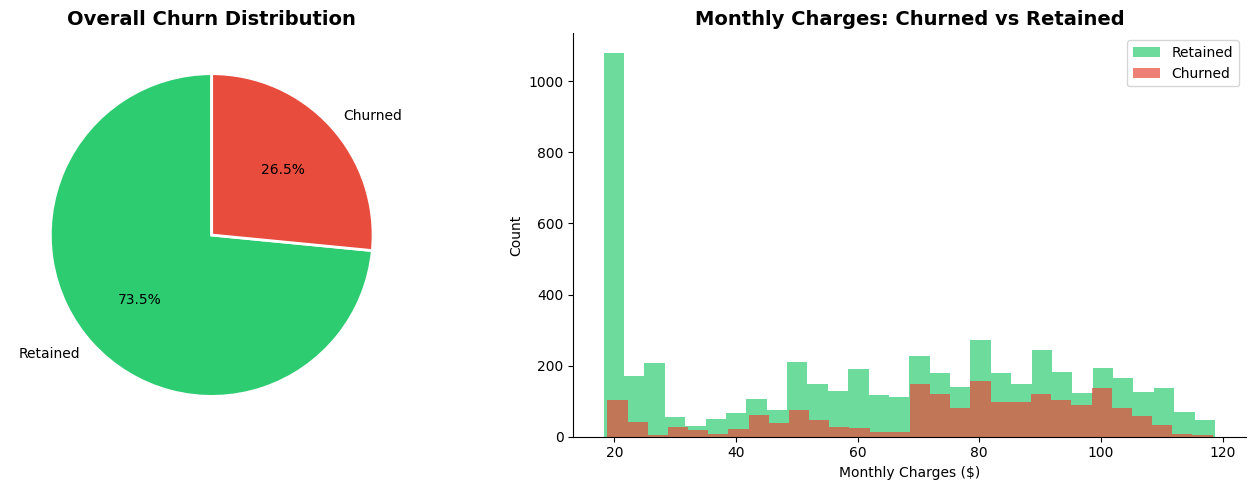

💡 Insight: Higher monthly charges correlate with higher churn


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn distribution pie
churn_counts = df['Churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(churn_counts, labels=['Retained', 'Churned'], autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Overall Churn Distribution', fontsize=14, fontweight='bold')

# Monthly charges distribution
axes[1].hist(df[df['Churn']=='No']['MonthlyCharges'], bins=30, alpha=0.7, label='Retained', color='#2ecc71')
axes[1].hist(df[df['Churn']=='Yes']['MonthlyCharges'], bins=30, alpha=0.7, label='Churned', color='#e74c3c')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')
axes[1].set_title('Monthly Charges: Churned vs Retained', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Higher monthly charges correlate with higher churn")


### 📈 Monthly Churn Trend (by Tenure)

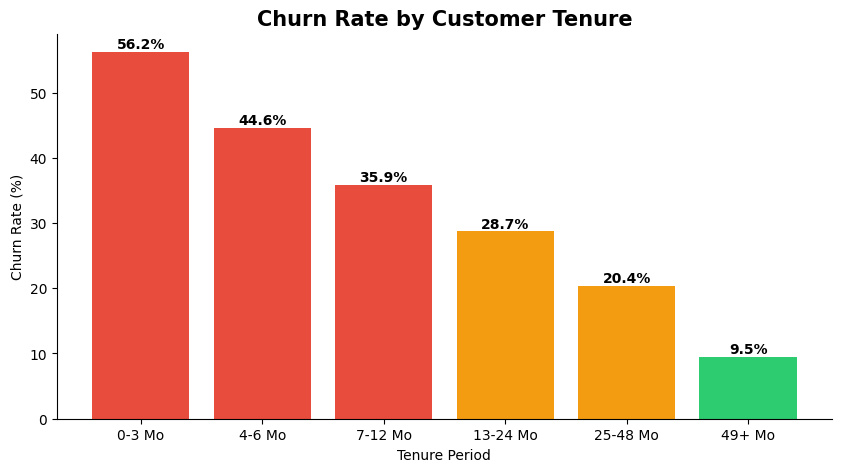

💡 Insight: New customers (0-3 months) churn most — onboarding is critical!


In [4]:
# Bucket tenure into months
def tenure_bucket(t):
    if t <= 3: return '0-3 Mo'
    elif t <= 6: return '4-6 Mo'
    elif t <= 12: return '7-12 Mo'
    elif t <= 24: return '13-24 Mo'
    elif t <= 48: return '25-48 Mo'
    else: return '49+ Mo'

df['Tenure_Bucket'] = df['tenure'].apply(tenure_bucket)
order = ['0-3 Mo','4-6 Mo','7-12 Mo','13-24 Mo','25-48 Mo','49+ Mo']

churn_by_tenure = df.groupby('Tenure_Bucket')['Churn_Binary'].mean().reindex(order) * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(churn_by_tenure.index, churn_by_tenure.values,
               color=['#e74c3c' if v > 30 else '#f39c12' if v > 20 else '#2ecc71'
                      for v in churn_by_tenure.values])
plt.title('Churn Rate by Customer Tenure', fontsize=15, fontweight='bold')
plt.xlabel('Tenure Period')
plt.ylabel('Churn Rate (%)')
for bar, val in zip(bars, churn_by_tenure.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.savefig('churn_by_tenure.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: New customers (0-3 months) churn most — onboarding is critical!")


### 📋 Churn by Contract Type & Payment Method

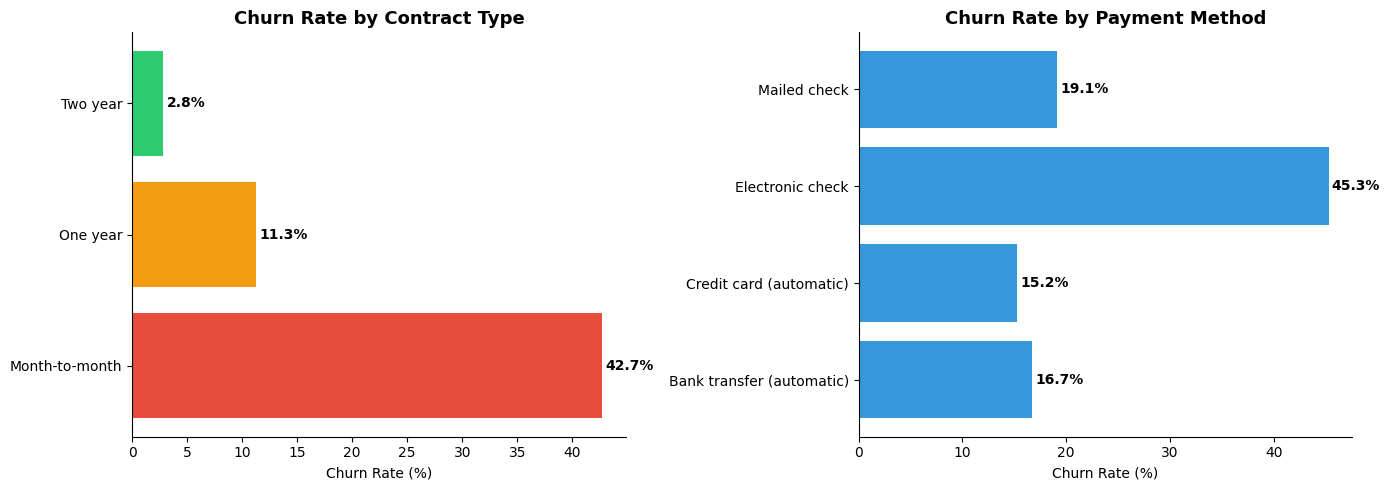

💡 Insight: Month-to-month customers + Electronic check = highest churn risk!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contract type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
axes[0].barh(contract_churn.index, contract_churn.values,
             color=['#e74c3c','#f39c12','#2ecc71'])
axes[0].set_title('Churn Rate by Contract Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)')
for i, v in enumerate(contract_churn.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

# Payment method
pay_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean() * 100
axes[1].barh(pay_churn.index, pay_churn.values, color='#3498db')
axes[1].set_title('Churn Rate by Payment Method', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churn Rate (%)')
for i, v in enumerate(pay_churn.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('churn_contract_payment.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Month-to-month customers + Electronic check = highest churn risk!")


### 🔧 Feature Usage Analysis

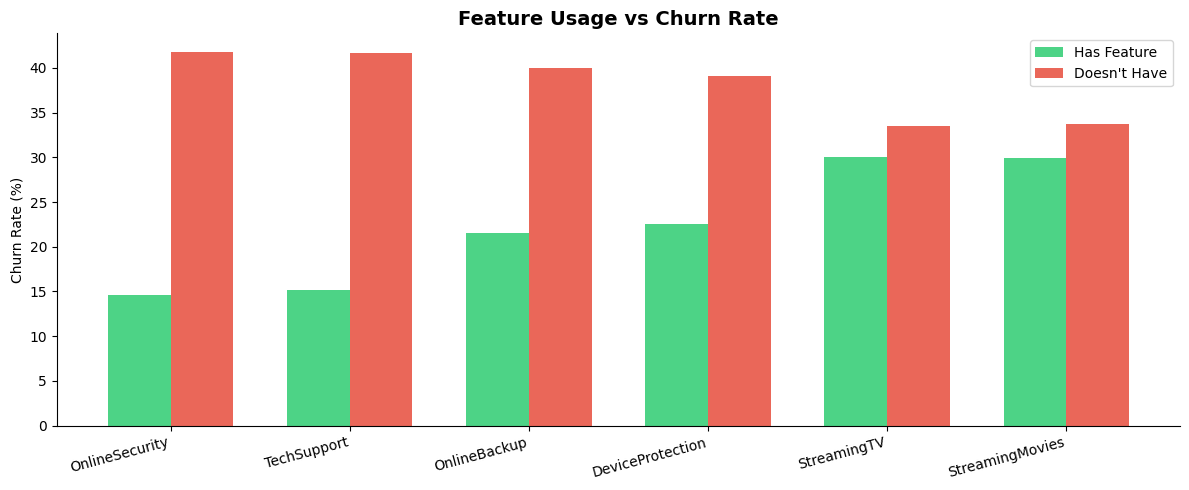

💡 Insight: Customers WITHOUT OnlineSecurity and TechSupport churn significantly more!


In [6]:
features = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection', 'StreamingTV', 'StreamingMovies']

churn_rates = {}
for feat in features:
    has = df[df[feat]=='Yes']['Churn_Binary'].mean() * 100
    hasnt = df[df[feat]=='No']['Churn_Binary'].mean() * 100
    churn_rates[feat] = {'Has Feature': has, "Doesn't Have": hasnt}

feat_df = pd.DataFrame(churn_rates).T

x = np.arange(len(feat_df))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - width/2, feat_df['Has Feature'], width, label='Has Feature', color='#2ecc71', alpha=0.85)
ax.bar(x + width/2, feat_df["Doesn't Have"], width, label="Doesn't Have", color='#e74c3c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(feat_df.index, rotation=15, ha='right')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Feature Usage vs Churn Rate', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('feature_usage_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Customers WITHOUT OnlineSecurity and TechSupport churn significantly more!")


## 🤖 Step 3: Churn Prediction Model (Random Forest)

In [7]:
# Encode categorical columns
df_model = df.copy()
le = LabelEncoder()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols = [c for c in cat_cols if c not in ['customerID', 'Churn']]

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

features_cols = [c for c in df_model.columns if c not in ['customerID', 'Churn', 'Churn_Binary', 'Tenure_Bucket']]
X = df_model[features_cols]
y = df_model['Churn_Binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
roc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])

print(f"✅ Model Trained!")
print(f"🎯 ROC-AUC Score: {roc:.3f}")
print(f"\n📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))


✅ Model Trained!
🎯 ROC-AUC Score: 0.823

📋 Classification Report:
              precision    recall  f1-score   support

    Retained       0.83      0.90      0.86      1035
     Churned       0.64      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



### 🏆 Leading Indicators of Churn (Feature Importance)

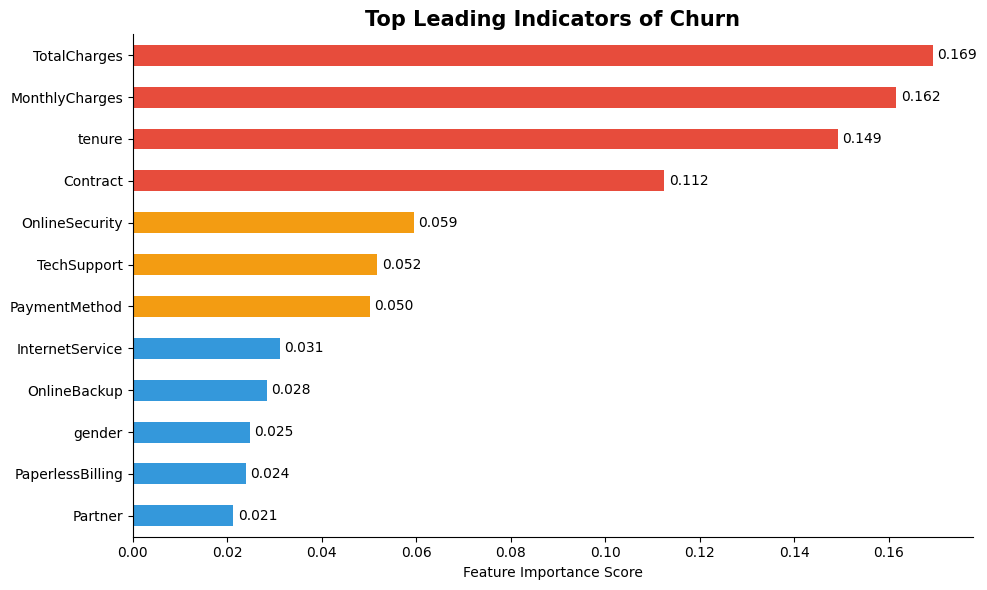

💡 Top predictors of churn identified!


In [8]:
importances = pd.Series(model.feature_importances_, index=features_cols)
importances = importances.sort_values(ascending=True).tail(12)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0.08 else '#f39c12' if v > 0.05 else '#3498db' for v in importances.values]
importances.plot(kind='barh', color=colors)
plt.title('Top Leading Indicators of Churn', fontsize=15, fontweight='bold')
plt.xlabel('Feature Importance Score')
for i, v in enumerate(importances.values):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Top predictors of churn identified!")


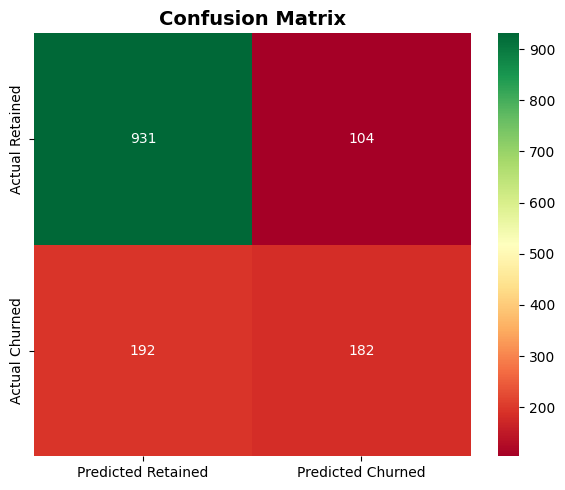

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Predicted Retained','Predicted Churned'],
            yticklabels=['Actual Retained','Actual Churned'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 💰 Step 4: Revenue at Risk Analysis

In [10]:
churned = df[df['Churn']=='Yes']
monthly_lost = churned['MonthlyCharges'].sum()
annual_lost = monthly_lost * 12
avg_charge = churned['MonthlyCharges'].mean()

print("=" * 45)
print("       💸 REVENUE AT RISK SUMMARY")
print("=" * 45)
print(f"  Customers Lost       : {len(churned):,}")
print(f"  Monthly Revenue Lost : ${monthly_lost:,.2f}")
print(f"  Annual Revenue Lost  : ${annual_lost:,.2f}")
print(f"  Avg Charge (Churned) : ${avg_charge:.2f}/mo")
print("=" * 45)

# By contract type
rev_by_contract = df[df['Churn']=='Yes'].groupby('Contract')['MonthlyCharges'].agg(['sum','count'])
rev_by_contract.columns = ['Monthly Revenue Lost', 'Customers Lost']
rev_by_contract['Annual Revenue Lost'] = rev_by_contract['Monthly Revenue Lost'] * 12
print("\n📋 Revenue Lost by Contract Type:")
print(rev_by_contract.round(2))


       💸 REVENUE AT RISK SUMMARY
  Customers Lost       : 1,869
  Monthly Revenue Lost : $139,130.85
  Annual Revenue Lost  : $1,669,570.20
  Avg Charge (Churned) : $74.44/mo

📋 Revenue Lost by Contract Type:
                Monthly Revenue Lost  Customers Lost  Annual Revenue Lost
Contract                                                                 
Month-to-month             120847.10            1655            1450165.2
One year                    14118.45             166             169421.4
Two year                     4165.30              48              49983.6


## 📋 Step 5: Churn Playbook (Action Plan)

In [11]:
# Score active customers by churn probability
active = df[df['Churn']=='No'].copy()
active_model = df_model[df_model['Churn_Binary']==0][features_cols]
active['Churn_Probability'] = model.predict_proba(active_model)[:,1]
active['Risk_Level'] = pd.cut(active['Churn_Probability'],
                               bins=[0, 0.3, 0.6, 1.0],
                               labels=['Low Risk', 'Medium Risk', 'High Risk'])

def assign_action(row):
    if row['tenure'] <= 3 and row['Contract'] == 'Month-to-month':
        return '📧 Send re-engagement email'
    elif row['MonthlyCharges'] > 80 and row['TechSupport'] == 'No':
        return '🎯 Assign dedicated support agent'
    elif row['OnlineSecurity'] == 'No' and row['InternetService'] != 'No':
        return '🔒 Offer OnlineSecurity add-on'
    elif row['Contract'] == 'Month-to-month' and row['tenure'] > 12:
        return '💰 Offer annual plan discount'
    elif row['Churn_Probability'] > 0.6:
        return '🚨 Urgent: Retention call'
    else:
        return '✅ Monitor'

active['Recommended_Action'] = active.apply(assign_action, axis=1)

playbook = active[['customerID','tenure','MonthlyCharges','Contract',
                    'TechSupport','OnlineSecurity','Churn_Probability',
                    'Risk_Level','Recommended_Action']]

print("🔥 CHURN PLAYBOOK - Top 20 At-Risk Customers")
print("=" * 80)
top_risk = playbook.sort_values('Churn_Probability', ascending=False).head(20)
print(top_risk[['customerID','tenure','MonthlyCharges','Risk_Level','Recommended_Action']].to_string(index=False))

# Save full playbook
playbook.to_csv('churn_playbook.csv', index=False)
print("\n✅ Full Churn Playbook saved to: churn_playbook.csv")


🔥 CHURN PLAYBOOK - Top 20 At-Risk Customers
customerID  tenure  MonthlyCharges Risk_Level               Recommended_Action
5542-TBBWB       1           69.90  High Risk       📧 Send re-engagement email
2545-EBUPK       2           84.05  High Risk       📧 Send re-engagement email
4090-KPJIP       3           74.95  High Risk       📧 Send re-engagement email
8161-QYMTT       7           94.10  High Risk 🎯 Assign dedicated support agent
2254-DLXRI       1           79.15  High Risk       📧 Send re-engagement email
4445-ZJNMU       9           99.30  High Risk 🎯 Assign dedicated support agent
8739-XNIKG       5           84.00  High Risk 🎯 Assign dedicated support agent
4927-WWOOZ       2           91.45  High Risk       📧 Send re-engagement email
3320-VEOYC      14           95.60  High Risk 🎯 Assign dedicated support agent
1751-NCDLI      46           98.85  High Risk 🎯 Assign dedicated support agent
8622-ZLFKO       6           90.75  High Risk 🎯 Assign dedicated support agent
6630-UJZ

## ✅ Step 6: Key Findings & Business Recommendations

### 🔍 Root Cause Analysis

| # | Finding | Recommendation |
|---|---------|----------------|
| 1 | **Month-to-month contracts** have ~42% churn rate | Offer incentives to upgrade to annual contracts |
| 2 | **New customers (0-3 months)** churn most | Improve onboarding experience |
| 3 | **No OnlineSecurity** → significantly higher churn | Proactive upsell/free trial of security features |
| 4 | **No TechSupport** → higher churn | Assign support to high-value customers |
| 5 | **Electronic check** users churn most | Encourage auto-pay setup |
| 6 | **Fiber optic** users churn more than DSL | Investigate service quality issues |

### 💰 Financial Impact
- **$139,130+ monthly revenue** at risk from churned customers
- **$1.6M+ annual revenue** lost
- Retaining just **10% more customers** = ~$140K saved per year

### 📋 Churn Playbook Summary

| Trigger | Segment | Action |
|---------|---------|--------|
| Inactive ≤ 3 months, Month-to-month | New customers | Send re-engagement email |
| High-value + No TechSupport | Premium users | Assign dedicated support |
| No OnlineSecurity + Internet user | Feature gap | Offer security add-on |
| Month-to-month + tenure > 12 months | Loyal customers | Offer annual plan discount |
| Churn probability > 60% | High risk | Urgent retention call |

### 🛠️ Tools Used
- **Python** (pandas, scikit-learn, matplotlib, seaborn) — EDA + ML Model
- **SQL** — Business queries and aggregations  
- **Power BI** — Interactive dashboard (see `power_bi_guide.md`)
